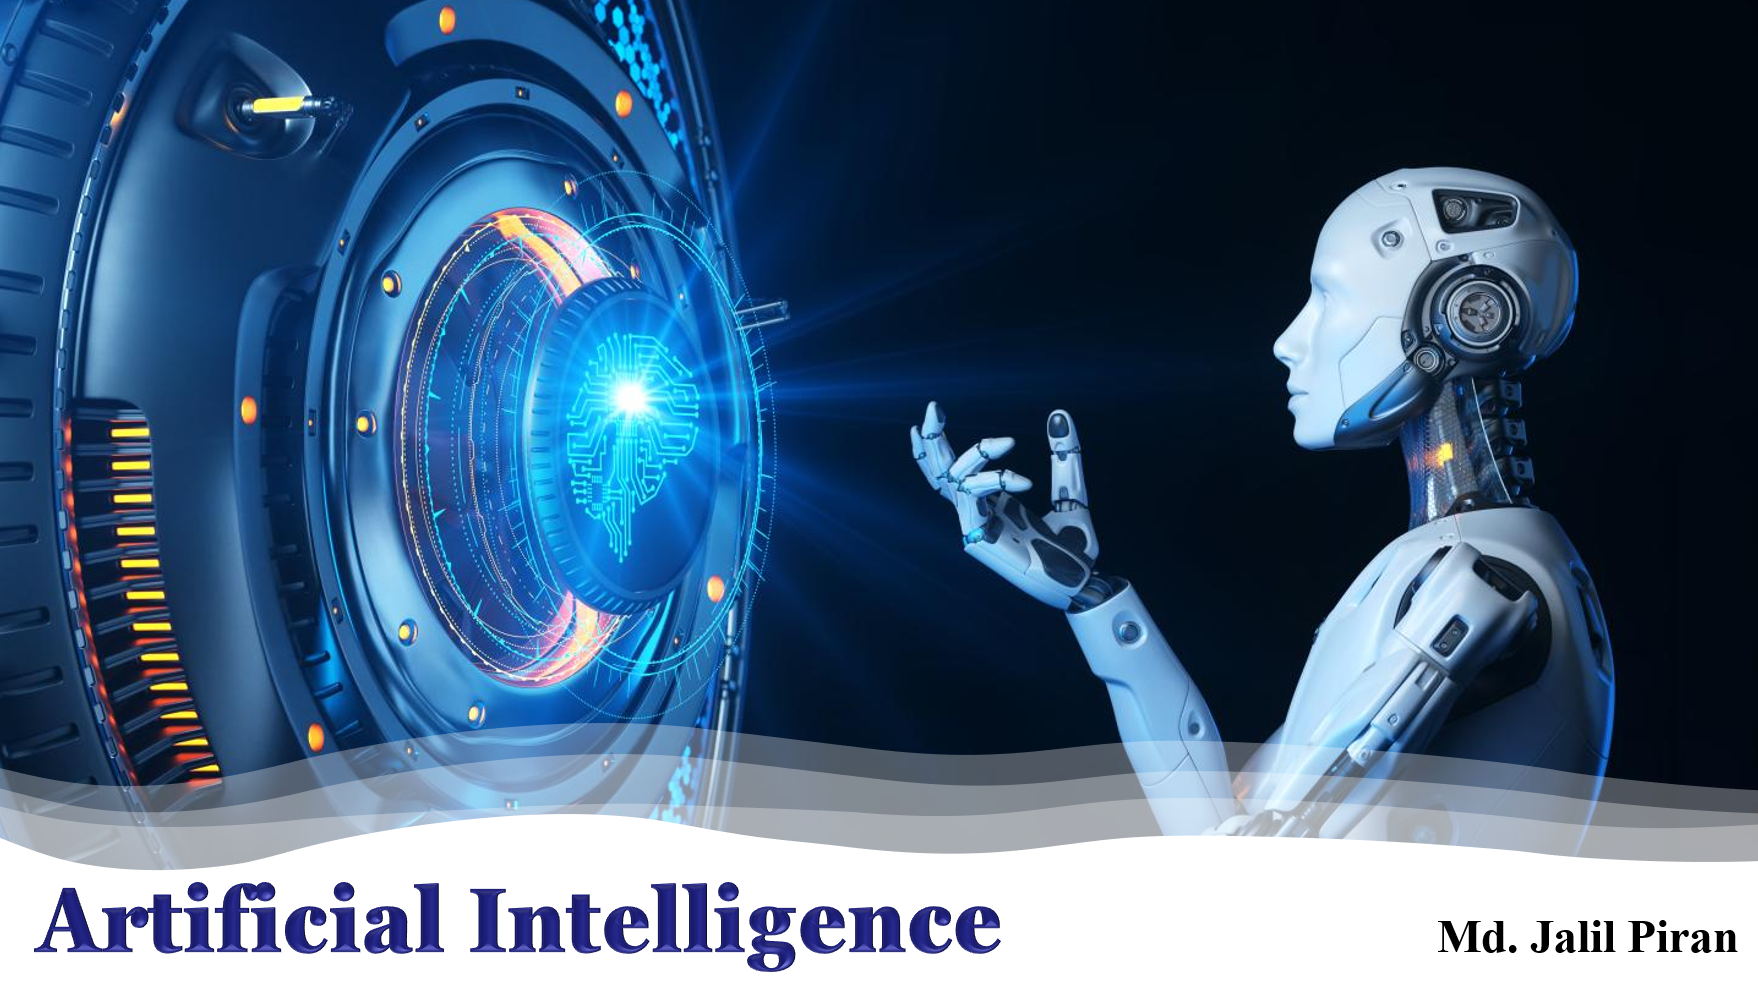

# Uninformed Search

* Run the code cells from top to bottom with Python 3.
* The visual examples require `networkx` and `matplotlib`.
* Install them with `%pip install networkx matplotlib` if needed.
* The numerical examples use only standard Python.
* Neighbour order determines traversal order when several choices are available.

## Breadth-First Search (BFS)

* **BFS with an adjacency list.**
  * The dictionary lists each node's outgoing neighbours.
  * BFS uses a first-in, first-out (FIFO) queue and marks nodes when they enter the queue, so a node reached through several edges is added only once.

In [1]:
graph = {
  '1' : ['2', '3','4'],
  '2' : ['5'],
  '3' : ['6'],
  '4' : ['6'],
  '5' : ['7'],
  '6' : ['7'],
  '7' : []
}
visited = []
queue = []

def bfs(visited, graph, node):
  visited.append(node)
  queue.append(node)
  while queue:          #visiting all nodes one by one
    m = queue.pop(0)
    print (m, end = " ")
    for neighbour in graph[m]:
      if neighbour not in visited:
        visited.append(neighbour)
        queue.append(neighbour)
print("Breadth-First Search")
bfs(visited, graph, '1')

Breadth-First Search
1 2 3 4 5 6 7 

* The output `1 2 3 4 5 6 7` is the nodes that are processed level by level, in the listed neighbour order.
* This is a traversal, not a single route; BFS finds minimum-edge paths when parent links are recorded.
* Here, `pop(0)` and list membership are linear-time operations, and the global queue must be reset before another call; the next example uses `deque` and a set.

* **Visualize BFS and recover a path.**
  * This example uses NetworkX to represent an undirected tree, `deque.popleft()` to remove the oldest queued node, and a parent dictionary to record each node's first discovery.
  * After the full traversal, it reconstructs the route to `K` by following parent links backward.

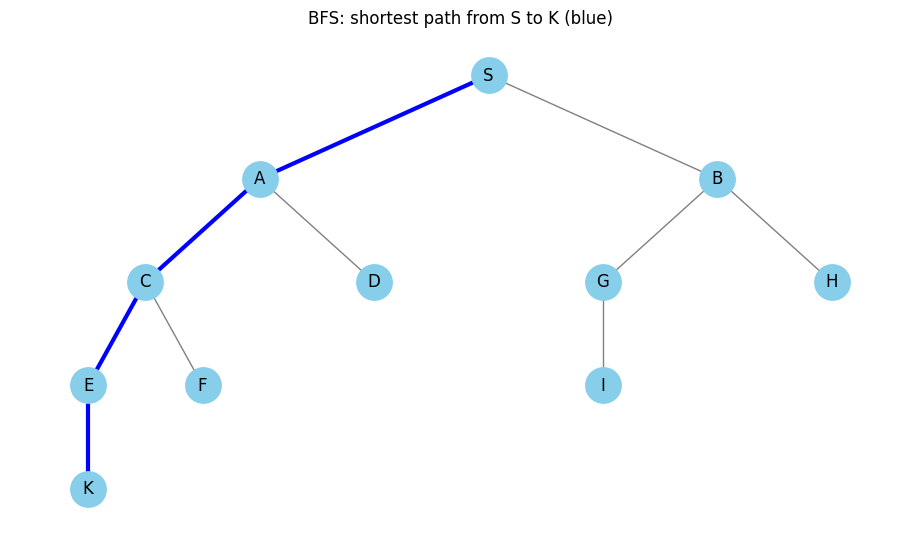

BFS traversal order: S -> A -> B -> C -> D -> G -> H -> E -> F -> I -> K
Shortest path from S to K: S -> A -> C -> E -> K


In [6]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque

def bfs_tree(graph, start):
    visited = {start}
    queue = deque([start])
    order = []
    parent = {start: None}
    while queue:
        node = queue.popleft()
        order.append(node)
        for neighbour in graph[node]:
            if neighbour not in visited:
                visited.add(neighbour)
                parent[neighbour] = node
                queue.append(neighbour)
    return order, parent

G = nx.Graph()
edges = [('S', 'A'), ('S', 'B'), ('A', 'C'), ('A', 'D'), ('B', 'G'),
         ('B', 'H'), ('C', 'E'), ('C', 'F'), ('G', 'I'), ('E', 'K')]
G.add_edges_from(edges)
order, parent = bfs_tree(G, 'S')
path = []
node = 'K'
while node is not None:
    path.append(node)
    node = parent[node]
path.reverse()

# Fixed positions show the tree without requiring Graphviz.
pos = {'S': (0, 0), 'A': (-2, -1), 'B': (2, -1),
       'C': (-3, -2), 'D': (-1, -2), 'G': (1, -2), 'H': (3, -2),
       'E': (-3.5, -3), 'F': (-2.5, -3), 'I': (1, -3), 'K': (-3.5, -4)}
plt.figure(figsize=(9, 5))
nx.draw(G, pos, with_labels=True, node_size=650, node_color='skyblue', edge_color='gray')
nx.draw_networkx_edges(G, pos, edgelist=list(zip(path, path[1:])), edge_color='blue', width=3)
plt.title('BFS: shortest path from S to K (blue)')
plt.show()
print('BFS traversal order:', ' -> '.join(order))
print('Shortest path from S to K:', ' -> '.join(path))

**Order versus path.**
  * The traversal is `S -> A -> B -> C -> D -> G -> H -> E -> F -> I -> K`, whereas the blue path is `S -> A -> C -> E -> K` (four edges).
  * Consecutive nodes in a traversal need not share an edge.
  * BFS guarantees a minimum-edge path in an unweighted graph, but not a minimum-cost path when edge costs differ.

## Depth-First Search (DFS)

**Recursive DFS on a tree:**
  * DFS explores an unvisited neighbour recursively before returning to try the next neighbour.
  * The visited set prevents revisits, the call stack supports backtracking, and the parent dictionary records the discovery edges used to reconstruct a path.

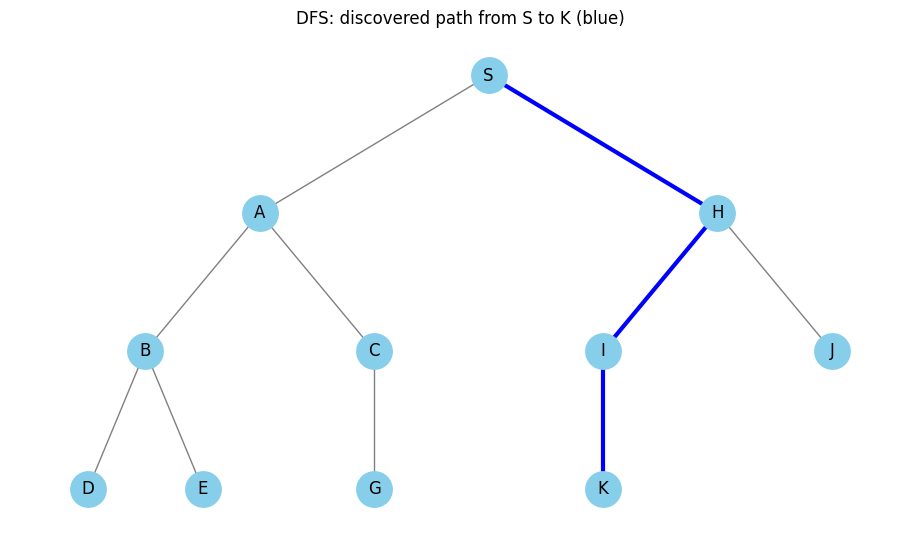

DFS traversal order: S -> A -> B -> D -> E -> C -> G -> H -> I -> K -> J
Discovered path from S to K: S -> H -> I -> K


In [7]:
import networkx as nx
import matplotlib.pyplot as plt

def dfs_tree(graph, node, visited, order, parent):
    visited.add(node)
    order.append(node)
    for neighbour in graph[node]:
        if neighbour not in visited:
            parent[neighbour] = node
            dfs_tree(graph, neighbour, visited, order, parent)

G = nx.Graph()
edges = [('S', 'A'), ('S', 'H'), ('A', 'B'), ('A', 'C'), ('B', 'D'),
         ('B', 'E'), ('C', 'G'), ('H', 'I'), ('H', 'J'), ('I', 'K')]
G.add_edges_from(edges)
order = []
parent = {'S': None}
dfs_tree(G, 'S', set(), order, parent)
path = []
node = 'K'
while node is not None:
    path.append(node)
    node = parent[node]
path.reverse()

pos = {'S': (0, 0), 'A': (-2, -1), 'H': (2, -1),
       'B': (-3, -2), 'C': (-1, -2), 'I': (1, -2), 'J': (3, -2),
       'D': (-3.5, -3), 'E': (-2.5, -3), 'G': (-1, -3), 'K': (1, -3)}
plt.figure(figsize=(9, 5))
nx.draw(G, pos, with_labels=True, node_size=650, node_color='skyblue', edge_color='gray')
nx.draw_networkx_edges(G, pos, edgelist=list(zip(path, path[1:])), edge_color='blue', width=3)
plt.title('DFS: discovered path from S to K (blue)')
plt.show()
print('DFS traversal order:', ' -> '.join(order))
print('Discovered path from S to K:', ' -> '.join(path))

**DFS backtracking.**
  * The traversal is `S -> A -> B -> D -> E -> C -> G -> H -> I -> K -> J`;
  * The blue route to `K` is `S -> H -> I -> K`. DFS continues through the whole tree in this example, even after visiting `K`.
  * A tree has only one simple path between two nodes; on a general graph, DFS does not guarantee a shortest path.

**DFS with an adjacency list.**
  * This compact version prints each node at its first visit and stores it in a set.
  * Neighbours are explored in list order, and recursion returns to earlier nodes when no unvisited neighbour remains.

In [8]:
#DFS
graph = {
  '1' : ['2', '3','4'],
  '2' : ['5'],
  '3' : ['6'],
  '4' : ['6'],
  '5' : ['7'],
  '6' : ['7'],
  '7' : []
}

visited = set()

def dfs(visited, graph, node):
    if node not in visited:
        print (node)
        visited.add(node)
        for neighbour in graph[node]:
            dfs(visited, graph, neighbour)

print("Following is the Depth-First Search")
dfs(visited, graph, '1')

Following is the Depth-First Search
1
2
5
7
3
6
4


**Follow the recursion.**
  * The output is `1, 2, 5, 7, 3, 6, 4`, with one node per line. Node `7` is not printed again when reached from `6`, because it is already visited.
  * With adjacency lists and expected constant-time set membership, this traversal takes $O(V+E)$ time over the reachable graph; very deep graphs can exceed Python's recursion limit.

## **Iterative Deepening Search (IDS)**

* IDS repeats depth-limited DFS with limits of 0, 1, 2, and so on, up to the inclusive `max_depth`.
* Each attempt starts afresh; the current path prevents cycles, and a successful call returns the actual route rather than an exploration log.

In [9]:
graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['G'],
    'D': [],
    'E': ['F'],
    'G': [],
    'F': []
}

def depth_limited_search(graph, current, goal, remaining_depth, path):
    print('Checking for destination', current)
    if current == goal:
        return path.copy()
    if remaining_depth == 0:
        return None
    for neighbour in graph[current]:
        if neighbour not in path:  # Avoid cycles within the current path.
            result = depth_limited_search(
                graph, neighbour, goal, remaining_depth - 1, path + [neighbour]
            )
            if result is not None:
                return result
    return None

def iterative_deepening_search(graph, start, goal, max_depth):
    for limit in range(max_depth + 1):  # Include max_depth; root depth is zero.
        print(f'\nDepth limit: {limit}')
        result = depth_limited_search(graph, start, goal, limit, [start])
        if result is not None:
            return result
    return None

path = iterative_deepening_search(graph, 'A', 'G', max_depth=4)
if path is None:
    print('No path found within the depth limit.')
else:
    print('A path exists:', ' -> '.join(path))


Depth limit: 0
Checking for destination A

Depth limit: 1
Checking for destination A
Checking for destination B
Checking for destination C

Depth limit: 2
Checking for destination A
Checking for destination B
Checking for destination D
Checking for destination E
Checking for destination C
Checking for destination G
A path exists: A -> C -> G


* The checks are `A` at limit 0; `A, B, C` at limit 1; and `A, B, D, E, C, G` at limit 2.
* The returned path is `A -> C -> G`.
* Repeated visits across iterations are intentional: IDS finds a shallowest goal when the bound is sufficient, and this is cost-optimal only when all step costs are equal.
* Failure here means no path was found within the chosen bound.

## **Uniform-Cost Search (UCS)**

* UCS expands the frontier entry with the smallest accumulated cost $g(n)$, not the smallest depth.
* `heapq.heappush` maintains a min-heap and `heapq.heappop` removes its minimum; tuples compare their first element (`cost`) first, while `Node.__lt__` handles comparisons if those costs tie.
* This implementation requires nonnegative edge costs.

In [10]:
import heapq
class Node:
    def __init__(self, name, cost):
        self.name = name
        self.cost = cost
    def __lt__(self, other):
        return self.cost < other.cost
def uniform_cost_search(graph, start, goal):
    visited = set()
    priority_queue = [(0, Node(start, 0))]
    while priority_queue:
        cost, current_node = heapq.heappop(priority_queue)
        if current_node.name in visited:
            continue
        visited.add(current_node.name)
        if current_node.name == goal:
            return cost
        for neighbor, neighbor_cost in graph[current_node.name]:
            if neighbor not in visited:
                heapq.heappush(priority_queue, (cost + neighbor_cost, Node(neighbor, cost + neighbor_cost)))
    return float('inf')

graph = {
    'S': [('A', 1), ('B', 4)],
    'A': [('C', 3), ('D', 2)],
    'B': [('G', 5)],
    'C': [('E', 5)],
    'E': [('G', 5)],
    'D': [('G', 3)],
    'G': []
}
start_node = 'S'
goal_node = 'G'
result = uniform_cost_search(graph, start_node, goal_node)
if result != float('inf'):
    print(f"The cost of the cheapest path from {start_node} to {goal_node} is {result}.")
else:
    print(f"There is no path from {start_node} to {goal_node}.")

The cost of the cheapest path from S to G is 6.


* The printed result is `6`, achieved by `S -> A -> D -> G` with cost $1+2+3$. The function returns only the cost, not the route.
* A node is finalized when removed from the heap, and later duplicate entries are skipped; the goal is accepted at removal, not at first discovery, which is essential for UCS optimality.

# Informed Search

## Greedy Search

**Choose the neighbour with the smallest heuristic.**
* This implementation follows one branch. It selects the smallest $h(n)$ among the current node's neighbours and ignores edge costs when making that choice.
* `visited` detects a cycle; `path` records the selected route. A dead end or a cycle causes failure without backtracking.
* This is a local greedy walk, not standard greedy best-first search, which keeps a frontier of all discovered candidates.
* The small correction `graph.get(current_node, [])` treats an omitted leaf as a dead end instead of raising `KeyError`.

In [13]:
def greedy(graph, H_table, start, goal):
    visited = set()
    path = []
    current_node = start

    while current_node != goal:
        path.append(current_node)
        visited.add(current_node)
        neighbors = graph.get(current_node, [])
        if not neighbors:
            return None  # Dead end on this branch.
        next_node = min(neighbors, key=lambda x: H_table[x[0]])
        current_node = next_node[0]
        if current_node in visited:
            return None  # Cycle on this branch.

    path.append(goal)
    return path

greedy_graph = {
    'S': [('A', 3), ('B', 2)],
    'A': [('C', 4), ('D', 1)],
    'B': [('E', 3), ('F', 1)],
    'E': [('H', 5)],
    'F': [('I', 2), ('G', 3)]
}
greedy_h = {
    'A': 12, 'B': 4, 'C': 7, 'D': 3, 'E': 8,
    'F': 2, 'H': 4, 'I': 9, 'S': 13, 'G': 0
}

def path_cost(graph, path):
    if path is None:
        return float('inf')
    return sum(next(cost for neighbor, cost in graph[u] if neighbor == v)
               for u, v in zip(path, path[1:]))

greedy_path = greedy(greedy_graph, greedy_h, 'S', 'G')
if greedy_path is not None:
    print('The found path:', ' -> '.join(greedy_path))
    print('Path cost:', path_cost(greedy_graph, greedy_path))
else:
    print('No path found by the greedy walk.')

The found path: S -> B -> F -> G
Path cost: 6


| Current node | Candidate heuristics | Selected node |
|---|---|---|
| S | A: 12, B: 4 | B |
| B | E: 8, F: 2 | F |
| F | I: 9, G: 0 | G |

The returned path is `S -> B -> F -> G`, with cost $2+1+3=6$. The costs are used only to report the total. If the walk fails, a different branch may still contain a route to the goal. Equal heuristic values are resolved by neighbour list order.

**Visualize the greedy path.** Nodes show their heuristic values, edges show their costs, and the selected route is blue.

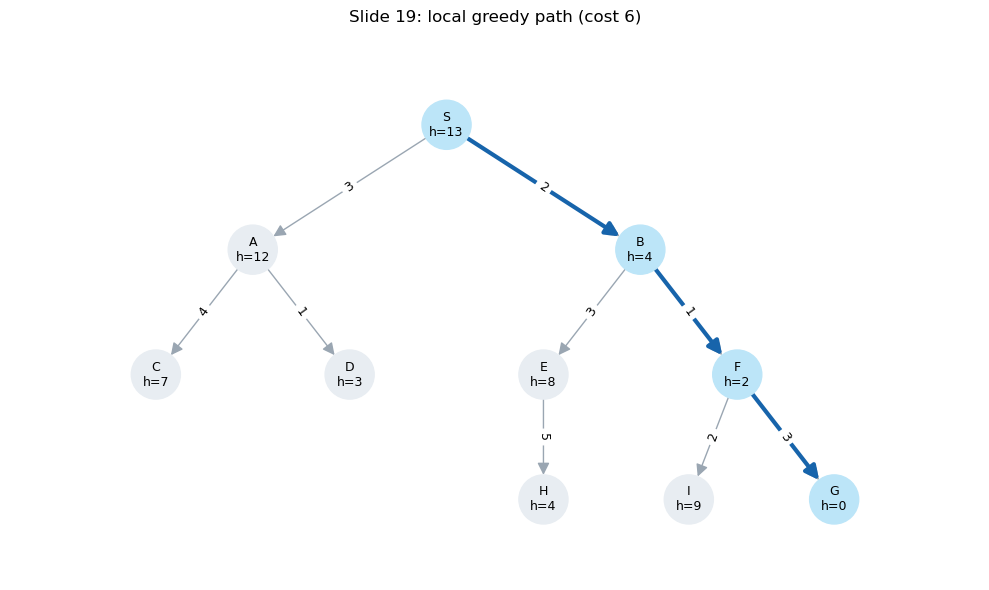

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

def draw_search_graph(graph, heuristics, path, positions, title,
                      directed=True, figsize=(10, 6)):
    G = nx.DiGraph() if directed else nx.Graph()
    G.add_nodes_from(heuristics)
    for node, neighbors in graph.items():
        for neighbor, cost in neighbors:
            G.add_edge(node, neighbor, weight=cost)
    plt.figure(figsize=figsize)
    labels = {node: f'{node}\nh={heuristics[node]}' for node in G}
    colors = ['#bce5f8' if path and node in path else '#e8edf2' for node in G]
    nx.draw_networkx(G, positions, labels=labels, node_color=colors,
                     node_size=1250, font_size=9, edge_color='#9aa6b2',
                     arrows=directed, arrowsize=18)
    nx.draw_networkx_edge_labels(G, positions,
        edge_labels=nx.get_edge_attributes(G, 'weight'), font_size=9)
    if path:
        nx.draw_networkx_edges(G, positions, edgelist=list(zip(path, path[1:])),
                               edge_color='#1764ab', width=3,
                               arrows=directed, arrowsize=20, node_size=1250)
    for text in plt.gca().texts:
        text.set_zorder(5)
    plt.title(title, pad=16)
    plt.axis('off')
    plt.margins(0.15)
    plt.tight_layout()
    plt.show()

greedy_positions = {
    'S': (0, 3), 'A': (-2, 2), 'B': (2, 2),
    'C': (-3, 1), 'D': (-1, 1), 'E': (1, 1), 'F': (3, 1),
    'H': (1, 0), 'I': (2.5, 0), 'G': (4, 0)
}
draw_search_graph(greedy_graph, greedy_h, greedy_path, greedy_positions,
                  'Slide 19: local greedy path (cost 6)')

## A* with an Adjacency List

**Combine cost so far and estimated cost to go.**

$$f(n)=g(n)+h(n).$$

* `g_score` stores the cheapest discovered cost from the start. The heap prioritizes $f(n)$ across the entire frontier.
* Each entry stores `(f, tie_breaker, g, node, path)`. A counter resolves ties in insertion order. Old entries are skipped if a cheaper route has already been recorded.
* The supplied code initialized the start priority to zero and then subtracted its heuristic. Consequently, its priorities were shifted by $-h(S)$ rather than representing $g+h$. Here, the start priority is `H_table[start]`, and `g` is tracked explicitly.
* A better route creates a new heap entry, even for a previously expanded node. This permits reopening. Missing adjacency entries are treated as leaves.

In [4]:
import heapq
from itertools import count

def astar(graph, H_table, start, goal):
    tie_breaker = count()
    open_list = [(H_table[start], next(tie_breaker), 0, start, [])]
    g_score = {start: 0}

    while open_list:
        f, _, current_g, current_node, path = heapq.heappop(open_list)
        if current_g != g_score[current_node]:
            continue  # Ignore an entry superseded by a cheaper route.
        if current_node == goal:
            return path + [current_node]
        for neighbor, cost in graph.get(current_node, []):
            if cost < 0:
                raise ValueError('A* requires nonnegative edge costs here.')
            tentative_g = current_g + cost
            if tentative_g < g_score.get(neighbor, float('inf')):
                g_score[neighbor] = tentative_g
                next_f = tentative_g + H_table[neighbor]
                heapq.heappush(open_list,
                    (next_f, next(tie_breaker), tentative_g,
                     neighbor, path + [current_node]))
    return None

astar_graph = {
    'S': [('A', 1), ('G', 10)],
    'A': [('B', 2), ('C', 1)],
    'B': [('D', 5)],
    'C': [('D', 3), ('G', 4)]
}
astar_h = {'A': 3, 'B': 4, 'C': 2, 'D': 6, 'S': 5, 'G': 0}
astar_path = astar(astar_graph, astar_h, 'S', 'G')
if astar_path is not None:
    print('The best path is:', ' -> '.join(astar_path))
    print('Path cost:', path_cost(astar_graph, astar_path))
else:
    print('No path found.')

The best path is: S -> A -> C -> G
Path cost: 6



| Removed node | $g$ | $h$ | $f$ | Action |
|---|---:|---:|---:|---|
| S | 0 | 5 | 5 | Discover A and G |
| A | 1 | 3 | 4 | Discover B and C |
| C | 2 | 2 | 4 | Discover D; improve G from 10 to 6 |
| G | 6 | 0 | 6 | Return the goal path |

The route is `S -> A -> C -> G`, with cost $1+1+4=6$, compared with 10 for the direct edge. The goal is accepted when removed from the heap, not when first discovered.

**Heuristic conditions.** On a finite graph with nonnegative edge costs, this reopening implementation returns an optimal path when the heuristic is admissible and $h(G)=0$. Consistency additionally requires $h(u)\leq c(u,v)+h(v)$. The supplied table is inconsistent on `S -> A`, because $5>1+3$, but it is admissible for this directed graph. Nodes B and D cannot reach G, so their true remaining costs are infinite. Reopening matters when an admissible heuristic is inconsistent.

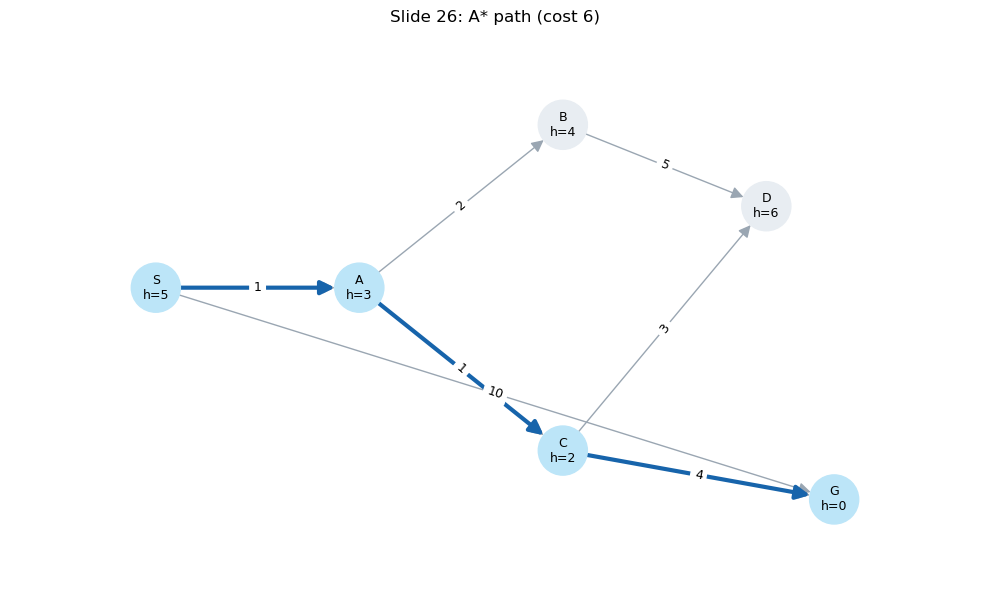

In [5]:
astar_positions = {'S': (0, 1), 'A': (1.5, 1), 'B': (3, 2),
                   'C': (3, 0), 'D': (4.5, 1.5), 'G': (5, -0.3)}
draw_search_graph(astar_graph, astar_h, astar_path, astar_positions,
                  'Slide 26: A* path (cost 6)')

## Object-Oriented A*: Romania Map

**Represent cities as objects.**
* Each `Node` stores its name, heuristic, neighbours, best discovered $g$ and $f$, and parent. The heuristic estimates distance to Bucharest in kilometres.
* `parent` links recover the route by tracing backward from the goal and then reversing the list.
* The original code changed `neighbor.f` while the object could still be inside the heap. Python does not automatically restore heap order after that mutation. This version pushes a fresh tuple with a fixed numeric priority after every improvement.
* All reachable nodes are reset before each call, so the same city objects can be reused. A counter handles tied priorities; `Node.__lt__` is therefore unnecessary. Improved nodes may be reopened.

In [8]:
import heapq
from itertools import count

class Node:
    def __init__(self, name, heuristic):
        self.name = name
        self.heuristic = heuristic
        self.adjacency_list = []
        self.g = float('inf')
        self.f = float('inf')
        self.parent = None

def a_star(start_node, goal_node):
    # Reset every reachable node before a new search.
    pending = [start_node]
    seen = set()
    while pending:
        node = pending.pop()
        if node in seen:
            continue
        seen.add(node)
        node.g = node.f = float('inf')
        node.parent = None
        pending.extend(neighbor for neighbor, _ in node.adjacency_list)

    start_node.g = 0
    start_node.f = start_node.heuristic
    tie_breaker = count()
    open_list = [(start_node.f, next(tie_breaker), 0, start_node)]
    while open_list:
        _, _, saved_g, current_node = heapq.heappop(open_list)
        if saved_g != current_node.g:
            continue
        if current_node is goal_node:
            path = []
            while current_node is not None:
                path.append(current_node.name)
                current_node = current_node.parent
            return path[::-1]
        for neighbor, cost in current_node.adjacency_list:
            if cost < 0:
                raise ValueError('A* requires nonnegative edge costs here.')
            tentative_g = current_node.g + cost
            if tentative_g < neighbor.g:
                neighbor.parent = current_node
                neighbor.g = tentative_g
                neighbor.f = tentative_g + neighbor.heuristic
                heapq.heappush(open_list,
                    (neighbor.f, next(tie_breaker), neighbor.g, neighbor))
    return None

In [9]:
arad = Node('Arad', 366)
bucharest = Node('Bucharest', 0)
craiova = Node('Craiova', 160)
dobreta = Node('Dobreta', 242)
eforie = Node('Eforie', 161)
fagaras = Node('Fagaras', 178)
giurgiu = Node('Giurgiu', 77)
hirsova = Node('Hirsova', 151)
iasi = Node('Iasi', 226)
lugoj = Node('Lugoj', 244)
mehadia = Node('Mehadia', 241)
neamt = Node('Neamt', 234)
oradea = Node('Oradea', 380)
pitesti = Node('Pitesti', 98)
rimnicu_vilcea = Node('Rimnicu Vilcea', 193)
sibiu = Node('Sibiu', 253)
timisoara = Node('Timisoara', 329)
urziceni = Node('Urziceni', 80)
vaslui = Node('Vaslui', 199)
zerind = Node('Zerind', 374)

In [10]:
arad.adjacency_list = [(zerind, 75), (sibiu, 140), (timisoara, 118)]
zerind.adjacency_list = [(arad, 75), (oradea, 71)]
oradea.adjacency_list = [(zerind, 71), (sibiu, 151)]
sibiu.adjacency_list = [(arad, 140), (oradea, 151), (fagaras, 99), (rimnicu_vilcea, 80)]
fagaras.adjacency_list = [(sibiu, 99), (bucharest, 211)]
rimnicu_vilcea.adjacency_list = [(sibiu, 80), (pitesti, 97), (craiova, 146)]
pitesti.adjacency_list = [(rimnicu_vilcea, 97), (bucharest, 101)]
timisoara.adjacency_list = [(arad, 118), (lugoj, 111)]
lugoj.adjacency_list = [(timisoara, 111), (mehadia, 70)]
mehadia.adjacency_list = [(lugoj, 70), (dobreta, 75)]
dobreta.adjacency_list = [(mehadia, 75), (craiova, 120)]
craiova.adjacency_list = [(dobreta, 120), (rimnicu_vilcea, 146), (pitesti, 138)]
bucharest.adjacency_list = [(fagaras, 211), (pitesti, 101), (giurgiu, 90), (urziceni, 85)]
giurgiu.adjacency_list = [(bucharest, 90)]
urziceni.adjacency_list = [(bucharest, 85), (hirsova, 98), (vaslui, 142)]
hirsova.adjacency_list = [(urziceni, 98), (eforie, 86)]
eforie.adjacency_list = [(hirsova, 86)]
vaslui.adjacency_list = [(urziceni, 142), (iasi, 92)]
iasi.adjacency_list = [(vaslui, 92), (neamt, 87)]
neamt.adjacency_list = [(iasi, 87)]

In [11]:
romania_path = a_star(arad, bucharest)
if romania_path is not None:
    print('Path from Arad to Bucharest:', ' -> '.join(romania_path))
    print('Total distance:', bucharest.g, 'km')
else:
    print('No path found.')

Path from Arad to Bucharest: Arad -> Sibiu -> Rimnicu Vilcea -> Pitesti -> Bucharest
Total distance: 418 km



The returned route is `Arad -> Sibiu -> Rimnicu Vilcea -> Pitesti -> Bucharest`, with total distance $140+80+97+101=418$ km. The route through Fagaras costs $140+99+211=450$ km.

| Node removed | $g$ | $h$ | $f$ |
|---|---:|---:|---:|
| Arad | 0 | 366 | 366 |
| Sibiu | 140 | 253 | 393 |
| Rimnicu Vilcea | 220 | 193 | 413 |
| Fagaras | 239 | 178 | 417 |
| Pitesti | 317 | 98 | 415 |
| Bucharest | 418 | 0 | 418 |

Fagaras first discovers Bucharest at cost 450; Pitesti improves that cost to 418. Expanding Fagaras does not put it on the final route. The supplied heuristic is inconsistent on `Sibiu -> Fagaras` because $253>99+178$; the implementation supports reopening. The values are retained rather than silently replaced with another Romania heuristic table.

**Visualize the full road network.** The layout is schematic, not geographic. For readability, reciprocal roads are drawn as single lines; the one-way Craiova-to-Pitesti connection is marked with an arrow. Node labels include the supplied heuristics.

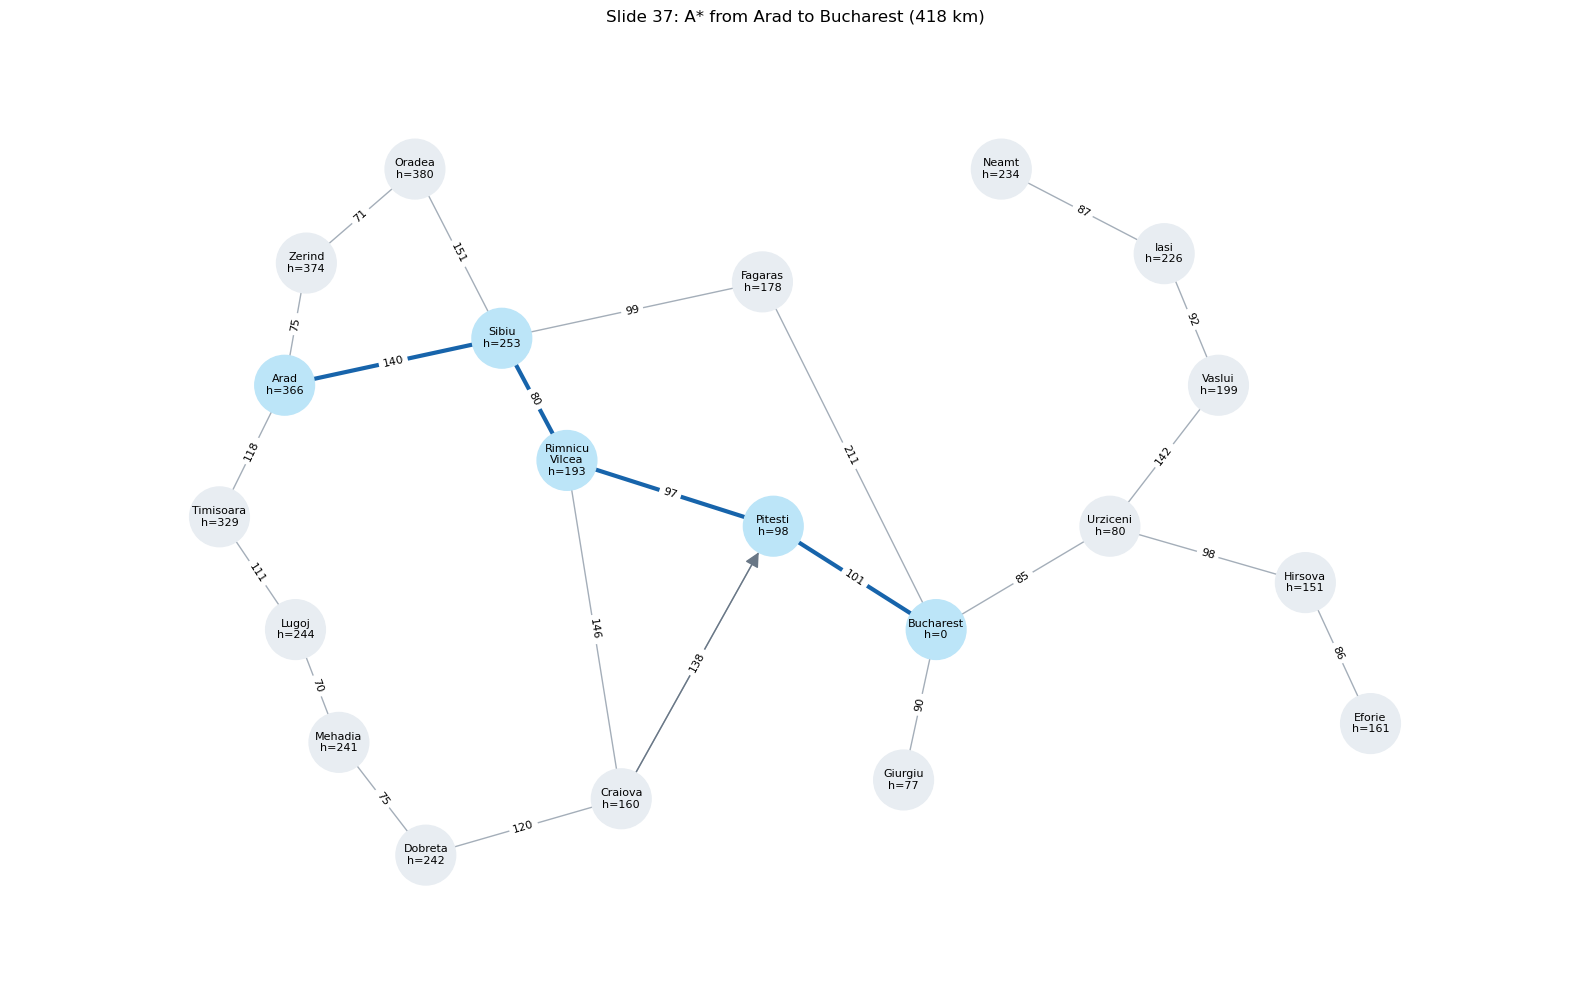

In [12]:
cities = [arad, bucharest, craiova, dobreta, eforie, fagaras, giurgiu, hirsova, iasi, lugoj, mehadia, neamt, oradea, pitesti, rimnicu_vilcea, sibiu, timisoara, urziceni, vaslui, zerind]

romania_graph = {city.name: [(neighbor.name, cost)
                 for neighbor, cost in city.adjacency_list] for city in cities}
romania_h = {city.name: city.heuristic for city in cities}
romania_positions = {
    'Arad': (0, 3.7), 'Zerind': (0.2, 5), 'Oradea': (1.2, 6),
    'Sibiu': (2, 4.2), 'Fagaras': (4.4, 4.8),
    'Rimnicu Vilcea': (2.6, 2.9), 'Pitesti': (4.5, 2.2),
    'Timisoara': (-0.6, 2.3), 'Lugoj': (0.1, 1.1),
    'Mehadia': (0.5, -0.1), 'Dobreta': (1.3, -1.3),
    'Craiova': (3.1, -0.7), 'Bucharest': (6, 1.1),
    'Giurgiu': (5.7, -0.5), 'Urziceni': (7.6, 2.2),
    'Hirsova': (9.4, 1.6), 'Eforie': (10, 0.1),
    'Vaslui': (8.6, 3.7), 'Iasi': (8.1, 5.1), 'Neamt': (6.6, 6)
}
# Draw reciprocal roads once, then show the asymmetric road explicitly.
G = nx.Graph()
for city, neighbors in romania_graph.items():
    for neighbor, cost in neighbors:
        G.add_edge(city, neighbor, weight=cost)
plt.figure(figsize=(16, 10))
labels = {city: city.replace(' ', '\n') + f'\nh={romania_h[city]}' for city in G}
nx.draw_networkx(G, romania_positions, labels=labels, node_size=1850,
    node_color=['#bce5f8' if city in romania_path else '#e8edf2' for city in G],
    font_size=8, edge_color='#a4aeb9')
nx.draw_networkx_edge_labels(G, romania_positions,
    edge_labels=nx.get_edge_attributes(G, 'weight'), font_size=8)
nx.draw_networkx_edges(G, romania_positions,
    edgelist=list(zip(romania_path, romania_path[1:])),
    edge_color='#1764ab', width=3, node_size=1850)
arrow_graph = nx.DiGraph()
arrow_graph.add_edge('Craiova', 'Pitesti')
nx.draw_networkx_edges(arrow_graph, romania_positions,
    node_size=1850, arrows=True, arrowsize=22, edge_color='#697786')
for text in plt.gca().texts:
    text.set_zorder(5)
plt.title('Slide 37: A* from Arad to Bucharest (418 km)', pad=16)
plt.axis('off')
plt.margins(0.12)
plt.tight_layout()
plt.show()

| Method | Selection rule | Retains alternative branches? | Minimum-cost guarantee |
|---|---|---|---|
| Slide 19 local greedy walk | Smallest neighbour $h$ | No | No |
| Standard greedy best-first search | Smallest frontier $h$ | Yes | No |
| A* in this notebook | Smallest frontier $g+h$ | Yes | With admissible $h$, $h(G)=0$, nonnegative costs, and reopening on a finite graph |
| Uniform-cost search | Smallest frontier $g$ | Yes | With nonnegative costs on a finite graph |

Setting all heuristic values to zero makes A* use the same priority rule as uniform-cost search. Changing the goal also requires a heuristic appropriate to the new goal; the Romania values above estimate distance to Bucharest only.